# Import Library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import random
import os

In [ ]:
# Define the seed value (42 is a standard convention in ML, but any integer works)
SEED = 42

# 1. Set seed for Python's built-in random module
random.seed(SEED)

# 2. Set seed for NumPy's random number generator (used in your data generation)
np.random.seed(SEED)

# 3. Optional: Set a deterministic behavior for hash-based operations in Python
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"--- Random seed successfully set to {SEED} for reproducibility --- \n")

--- Random seed successfully set to 42 for reproducibility --- 



# Generate Data

In [ ]:
# Define the Logistic Growth Function
def logistic_growth(t, r, K, P0):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

In [ ]:
# Configuration
num_samples = 1000
t_31 = np.linspace(0, 30, 31)
P0_fixed = 20
X_data = []
y_data = []

In [ ]:
print("--- STEP 1: Generating Synthetic Data ---")
for i in range(num_samples):
    r_rand = np.random.uniform(0.05, 0.5)
    K_rand = np.random.uniform(500, 2000)

    curve = logistic_growth(t_31, r_rand, K_rand, P0_fixed)
    X_data.append(curve)
    y_data.append([r_rand, K_rand])

X_data = np.array(X_data)
y_data = np.array(y_data)

print(f"Generated {len(X_data)} samples.")
print(f"Shape of X (Inputs): {X_data.shape} -> (Samples, TimePoints)")
print(f"Shape of y (Targets): {y_data.shape} -> (Samples, [r, K])")
print(f"Sample raw target (first curve): r={y_data[0][0]:.4f}, K={y_data[0][1]:.4f}\n")

--- STEP 1: Generating Synthetic Data ---
Generated 1000 samples.
Shape of X (Inputs): (1000, 31) -> (Samples, TimePoints)
Shape of y (Targets): (1000, 2) -> (Samples, [r, K])
Sample raw target (first curve): r=0.2185, K=1926.0715



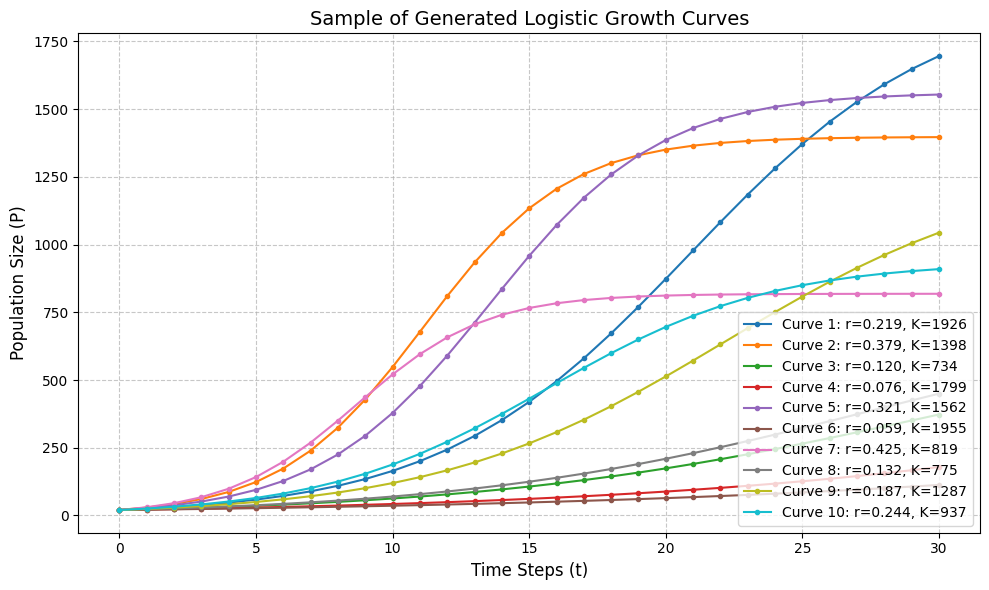

In [ ]:
import matplotlib.pyplot as plt

# Define the number of samples to plot (e.g., the first 5 samples)
num_samples_to_plot = 10

plt.figure(figsize=(10, 6))

for i in range(num_samples_to_plot):
    # Retrieve r and K values for the legend label
    r_val = y_data[i][0]
    K_val = y_data[i][1]

    # Plot the i-th curve
    plt.plot(t_31, X_data[i], marker='o', markersize=3,
             label=f'Curve {i+1}: r={r_val:.3f}, K={K_val:.0f}')

# Add title and axis labels
plt.title("Sample of Generated Logistic Growth Curves", fontsize=14)
plt.xlabel("Time Steps (t)", fontsize=12)
plt.ylabel("Population Size (P)", fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Initialize empty lists for the raw data
X_raw = []
y_raw = []

print("--- STEP 1: Generating Synthetic Data ---")
for i in range(num_samples):
    r_rand = np.random.uniform(0.05, 0.5)
    K_rand = np.random.uniform(500, 2000)

    # Generate the curve using the logistic growth function
    curve = logistic_growth(t_31, r_rand, K_rand, P0_fixed)

    # Append to the raw lists
    X_raw.append(curve)
    y_raw.append([r_rand, K_rand])

# Convert lists to NumPy arrays for faster computation
X_raw = np.array(X_raw)
y_raw = np.array(y_raw)

print(f"Generated {len(X_raw)} samples.")
print(f"Shape of X_raw (Inputs): {X_raw.shape} -> (Samples, TimePoints)")
print(f"Shape of y_raw (Targets): {y_raw.shape} -> (Samples, [r, K])")
print(f"Sample raw target (first curve): r={y_raw[0][0]:.4f}, K={y_raw[0][1]:.4f}\n")

--- STEP 1: Generating Synthetic Data ---
Generated 1000 samples.
Shape of X_raw (Inputs): (1000, 31) -> (Samples, TimePoints)
Shape of y_raw (Targets): (1000, 2) -> (Samples, [r, K])
Sample raw target (first curve): r=0.1678, K=870.4682



# If data is unnormalized

Training on RAW data: X_train shape = (700, 31)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Starting Training on Unnormalized Data ---
Training completed!



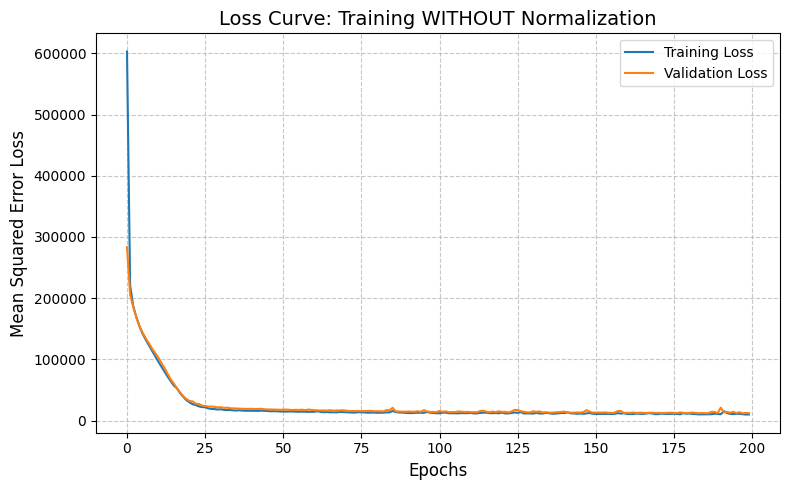

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

--- Testing Predictions vs Actual (First 3 Test Samples) ---
Sample 1:
  ACTUAL -> r: 0.317, K: 1370
  PREDICTED -> r: 1.231, K: 1363
----------------------------------------
Sample 2:
  ACTUAL -> r: 0.173, K: 619
  PREDICTED -> r: -3.588, K: 644
----------------------------------------
Sample 3:
  ACTUAL -> r: 0.499, K: 1900
  PREDICTED -> r: -9.758, K: 1870
----------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Split the RAW (unnormalized) data
# We use X_data and y_data directly instead of X_scaled and y_scaled
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_data, y_data, test_size=0.30, random_state=42
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, test_size=0.50, random_state=42
)

print(f"Training on RAW data: X_train shape = {X_train_raw.shape}")

# 2. Build the Feed-forward ANN architecture
# Structure: 31 (input) -> 64 (ReLU) -> 64 (ReLU) -> 32 (ReLU) -> 2 (Linear)
model_raw = Sequential([
    Dense(64, activation='relu', input_shape=(31,)), # First hidden layer
    Dense(64, activation='relu'),                    # Second hidden layer
    Dense(32, activation='relu'),                    # Third hidden layer
    Dense(2, activation='linear')                    # Output layer (r and K)
])

# 3. Compile the model
# Using Adam optimizer with learning rate 0.001 as instructed
optimizer = Adam(learning_rate=0.001)
# The custom loss formula in your image is mathematically equivalent to Mean Squared Error (MSE)
model_raw.compile(optimizer=optimizer, loss='mse')

# 4. Train the model
print("--- Starting Training on Unnormalized Data ---")
history_raw = model_raw.fit(
    X_train_raw, y_train_raw,
    validation_data=(X_val_raw, y_val_raw),
    epochs=200,
    batch_size=32,
    verbose=0 # Set to 1 if you want to see the loss at each epoch
)
print("Training completed!\n")

# 5. Plot the Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history_raw.history['loss'], label='Training Loss')
plt.plot(history_raw.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve: Training WITHOUT Normalization', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Let's look at the predictions
sample_predictions = model_raw.predict(X_test_raw[:3])
print("\n--- Testing Predictions vs Actual (First 3 Test Samples) ---")
for i in range(3):
    actual_r, actual_K = y_test_raw[i]
    pred_r, pred_K = sample_predictions[i]
    print(f"Sample {i+1}:")
    print(f"  ACTUAL -> r: {actual_r:.3f}, K: {actual_K:.0f}")
    print(f"  PREDICTED -> r: {pred_r:.3f}, K: {pred_K:.0f}")
    print("-" * 40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


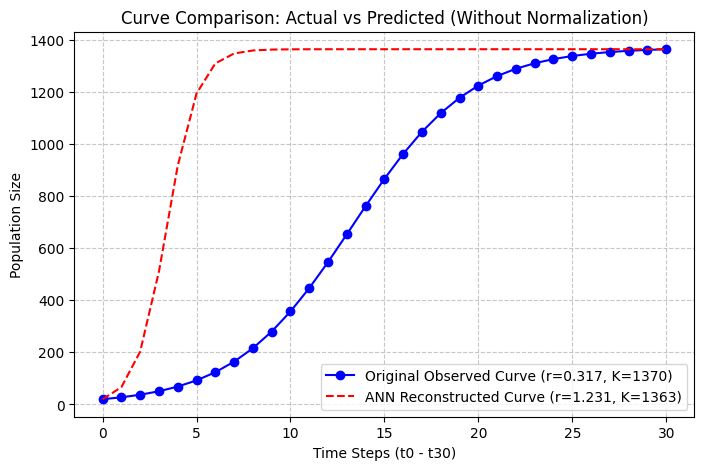

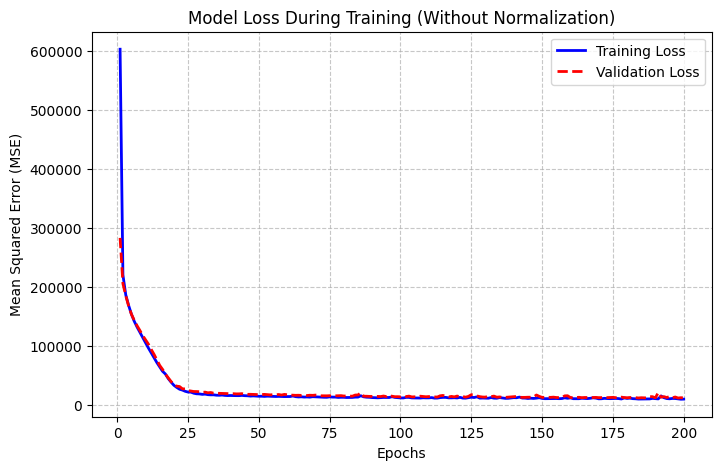

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select a specific sample from the unnormalized test set (e.g., the first one)
sample_index = 0

# Extract the true parameters
r_true = y_test_raw[sample_index][0]
K_true = y_test_raw[sample_index][1]

# Make a prediction using the unnormalized model
# We use .reshape(1, -1) because the model expects a 2D array (batch format)
predicted_params = model_raw.predict(X_test_raw[sample_index].reshape(1, -1))[0]
r_pred = predicted_params[0]
K_pred = predicted_params[1]

# Reconstruct the curves using the original and predicted parameters
reconstructed_curve = logistic_growth(t_31, r_pred, K_pred, P0_fixed)
original_curve = logistic_growth(t_31, r_true, K_true, P0_fixed)

# --- 1. Plot Curve Comparison ---
plt.figure(figsize=(8, 5))
plt.plot(t_31, original_curve, label=f'Original Observed Curve (r={r_true:.3f}, K={K_true:.0f})', color='blue', marker='o')
plt.plot(t_31, reconstructed_curve, label=f'ANN Reconstructed Curve (r={r_pred:.3f}, K={K_pred:.0f})', color='red', linestyle='dashed')
plt.title('Curve Comparison: Actual vs Predicted (Without Normalization)')
plt.xlabel('Time Steps (t0 - t30)')
plt.ylabel('Population Size')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 2. Plot Training and Validation Loss ---
# Grab the loss values from the unnormalized model's history
training_loss = history_raw.history['loss']
validation_loss = history_raw.history['val_loss']
epochs_range = range(1, len(training_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, validation_loss, label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.title('Model Loss During Training (Without Normalization)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Normalization

In [ ]:
print("--- STEP 2: Normalizing Data ---")

# GLOBAL normalization for X_data (To preserve the exact S-curve shape)
X_min = X_data.min() # Find the absolute minimum value across the entire array
X_max = X_data.max() # Find the absolute maximum value across the entire array
X_scaled = (X_data - X_min) / (X_max - X_min)

# PER-FEATURE normalization for y_data (Still using MinMaxScaler)
# Since r and K represent completely different metrics, they must be scaled individually per column
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_data)

--- STEP 2: Normalizing Data ---


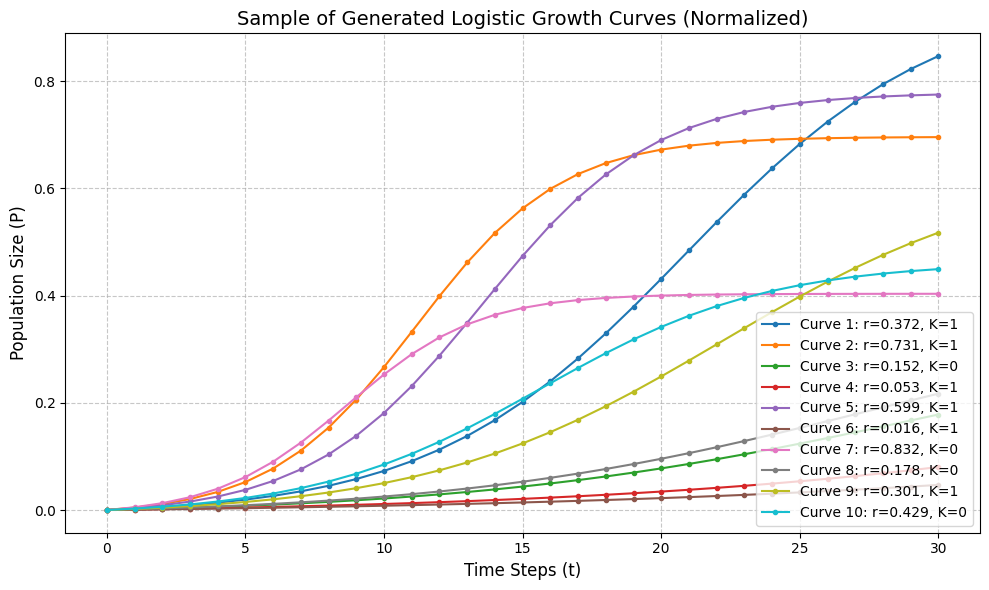

In [ ]:
import matplotlib.pyplot as plt

# Define the number of samples to plot (e.g., the first 5 samples)
num_samples_to_plot = 10

plt.figure(figsize=(10, 6))

for i in range(num_samples_to_plot):
    # Retrieve r and K values for the legend label
    r_val = y_scaled[i][0]
    K_val = y_scaled[i][1]

    # Plot the i-th curve
    plt.plot(t_31, X_scaled[i], marker='o', markersize=3,
             label=f'Curve {i+1}: r={r_val:.3f}, K={K_val:.0f}')

# Add title and axis labels
plt.title("Sample of Generated Logistic Growth Curves (Normalized)", fontsize=14)
plt.xlabel("Time Steps (t)", fontsize=12)
plt.ylabel("Population Size (P)", fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Display the plot
plt.tight_layout()
plt.show()

# Splitting Data

In [ ]:
# 3. Splitting
print("--- STEP 3: Splitting Dataset ---")
# First split: Separate 70% for training, 30% for "temporary" (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_scaled, test_size=0.30, random_state=42
)

--- STEP 3: Splitting Dataset ---


In [ ]:
# Second split: Split the 30% temporary into two halves (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Training set size   : {len(X_train)} samples")
print(f"Validation set size : {len(X_val)} samples")
print(f"Testing set size    : {len(X_test)} samples")
print("\nData Preparation Complete. Ready for ANN Training!")

Training set size   : 700 samples
Validation set size : 150 samples
Testing set size    : 150 samples

Data Preparation Complete. Ready for ANN Training!


# ANN Model

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, activation='relu', input_shape=(31,)), # Input 31 neuron
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='linear')                    # Output 2 neuron (r and K)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_val, y_val), verbose=1)

sample_idx = 5
X_unseen_scaled = X_test[sample_idx].reshape(1, -1)
y_true_scaled = y_test[sample_idx].reshape(1, -1)

# Estimation model r and K (still in scaled form)
y_pred_scaled = model.predict(X_unseen_scaled)

y_pred_true = scaler_y.inverse_transform(y_pred_scaled)[0]
y_true_true = scaler_y.inverse_transform(y_true_scaled)[0]

r_pred, K_pred = y_pred_true[0], y_pred_true[1]
r_true, K_true = y_true_true[0], y_true_true[1]

print(f"[Evaluasi]")
print(f"Target (Generate Data) -> r: {r_true:.3f}, K: {K_true:.1f}")
print(f"Estimasi Model         -> r: {r_pred:.3f}, K: {K_pred:.1f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.1416 - val_loss: 0.0601
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0581 - val_loss: 0.0507
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0493 - val_loss: 0.0447
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0419 - val_loss: 0.0385
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0361 - val_loss: 0.0352
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0324 - val_loss: 0.0325
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0298 - val_loss: 0.0309
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0276 - val_loss: 0.0287
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0247 - val_loss: 0.0252
Epoch 10/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0216 - val_loss: 0.0222
Epoch 11/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0188 - val_loss: 0.0196
Epoch 12/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

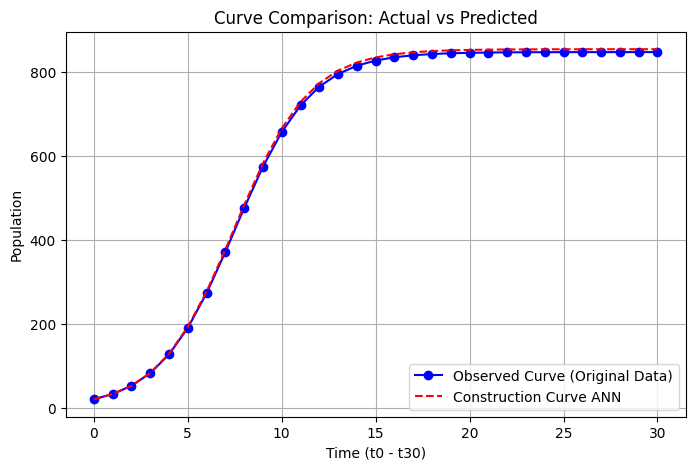

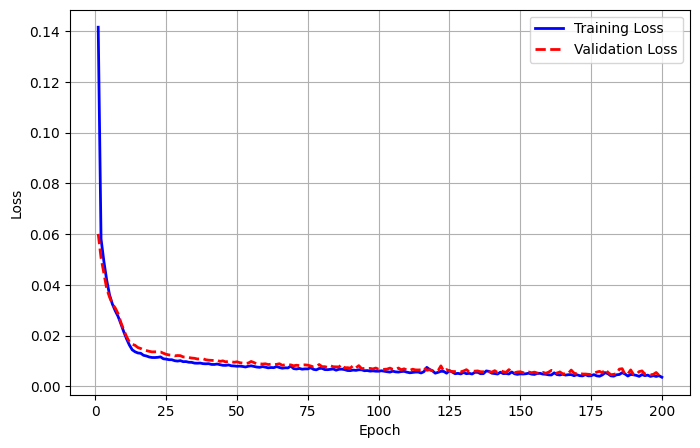

In [ ]:
reconstructed_curve = logistic_growth(t_31, r_pred, K_pred, P0_fixed)
original_curve = logistic_growth(t_31, r_true, K_true, P0_fixed)

plt.figure(figsize=(8, 5))
plt.plot(t_31, original_curve, label='Observed Curve (Original Data)', color='blue', marker='o')
plt.plot(t_31, reconstructed_curve, label='Construction Curve ANN', color='red', linestyle='dashed')
plt.xlabel('Time (t0 - t30)')
plt.ylabel('Population')
plt.title('Curve Comparison: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs_range = range(1, len(training_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, validation_loss, label='Validation Loss', color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

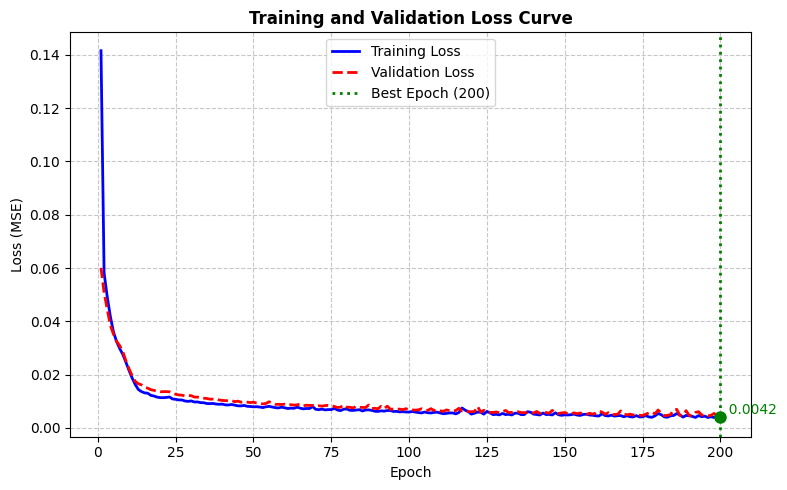

In [ ]:
import matplotlib.pyplot as plt

training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs_range = range(1, len(training_loss) + 1)

# Mencari epoch dengan validation loss paling rendah (terbaik)
best_val_loss = min(validation_loss)
best_epoch = validation_loss.index(best_val_loss) + 1  # Ditambah 1 karena index Python mulai dari 0, sedangkan epoch mulai dari 1

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, validation_loss, label='Validation Loss', color='red', linestyle='dashed', linewidth=2)

# Menambahkan garis vertikal (axvline) dan titik (plot) untuk Best Epoch
plt.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, label=f'Best Epoch ({best_epoch})')
plt.plot(best_epoch, best_val_loss, 'go', markersize=8) # 'go' berarti Green dot marker

# Opsional: Menambahkan teks nilai loss di dekat titik hijau agar lebih informatif
plt.text(best_epoch, best_val_loss, f'  {best_val_loss:.4f}', color='green', verticalalignment='bottom')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curve', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


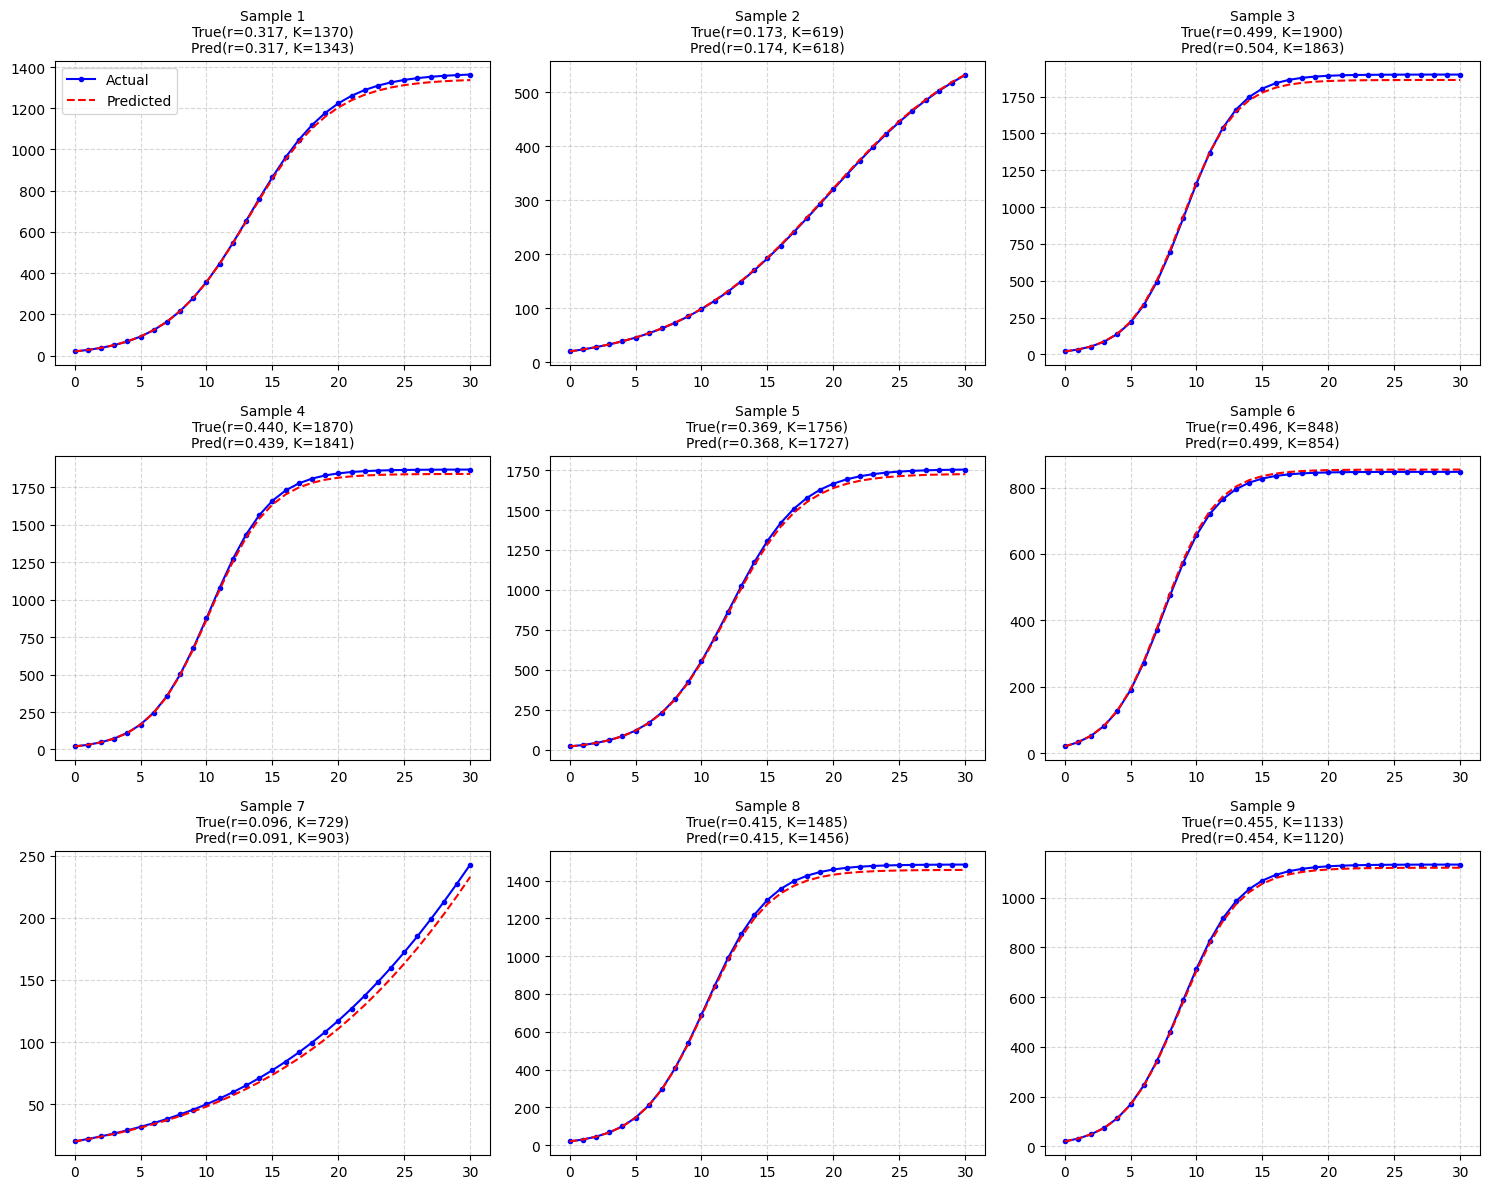

In [ ]:
import matplotlib.pyplot as plt

# Define how many samples to display (e.g., the first 9 samples)
num_samples = 9

# Generate predictions for the entire test set
y_pred_scaled_all = model.predict(X_test)

# Inverse transform y_test (true values) and y_pred_scaled_all (predicted values)
y_true_unscaled = scaler_y.inverse_transform(y_test)
y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled_all)

# Create a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() # Flatten the axes array for easy iteration

for i in range(num_samples):
    # Extract the true and predicted values for the i-th sample
    r_true, K_true = y_true_unscaled[i]
    r_pred, K_pred = y_pred_unscaled[i]

    # Reconstruct the curves
    original_curve = logistic_growth(t_31, r_true, K_true, P0_fixed)
    reconstructed_curve = logistic_growth(t_31, r_pred, K_pred, P0_fixed)

    # Plot on the i-th subplot
    axes[i].plot(t_31, original_curve, label='Actual', color='blue', marker='o', markersize=3)
    axes[i].plot(t_31, reconstructed_curve, label='Predicted', color='red', linestyle='dashed')

    # Set the title for each subplot with the r and K values
    axes[i].set_title(f'Sample {i+1}\nTrue(r={r_true:.3f}, K={K_true:.0f})\nPred(r={r_pred:.3f}, K={K_pred:.0f})', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Show the legend only in the first subplot to avoid visual clutter
    if i == 0:
        axes[i].legend()

plt.tight_layout() # Adjust subplot spacing to prevent overlapping
plt.show()

Displaying the top 9 curves with the highest prediction errors...


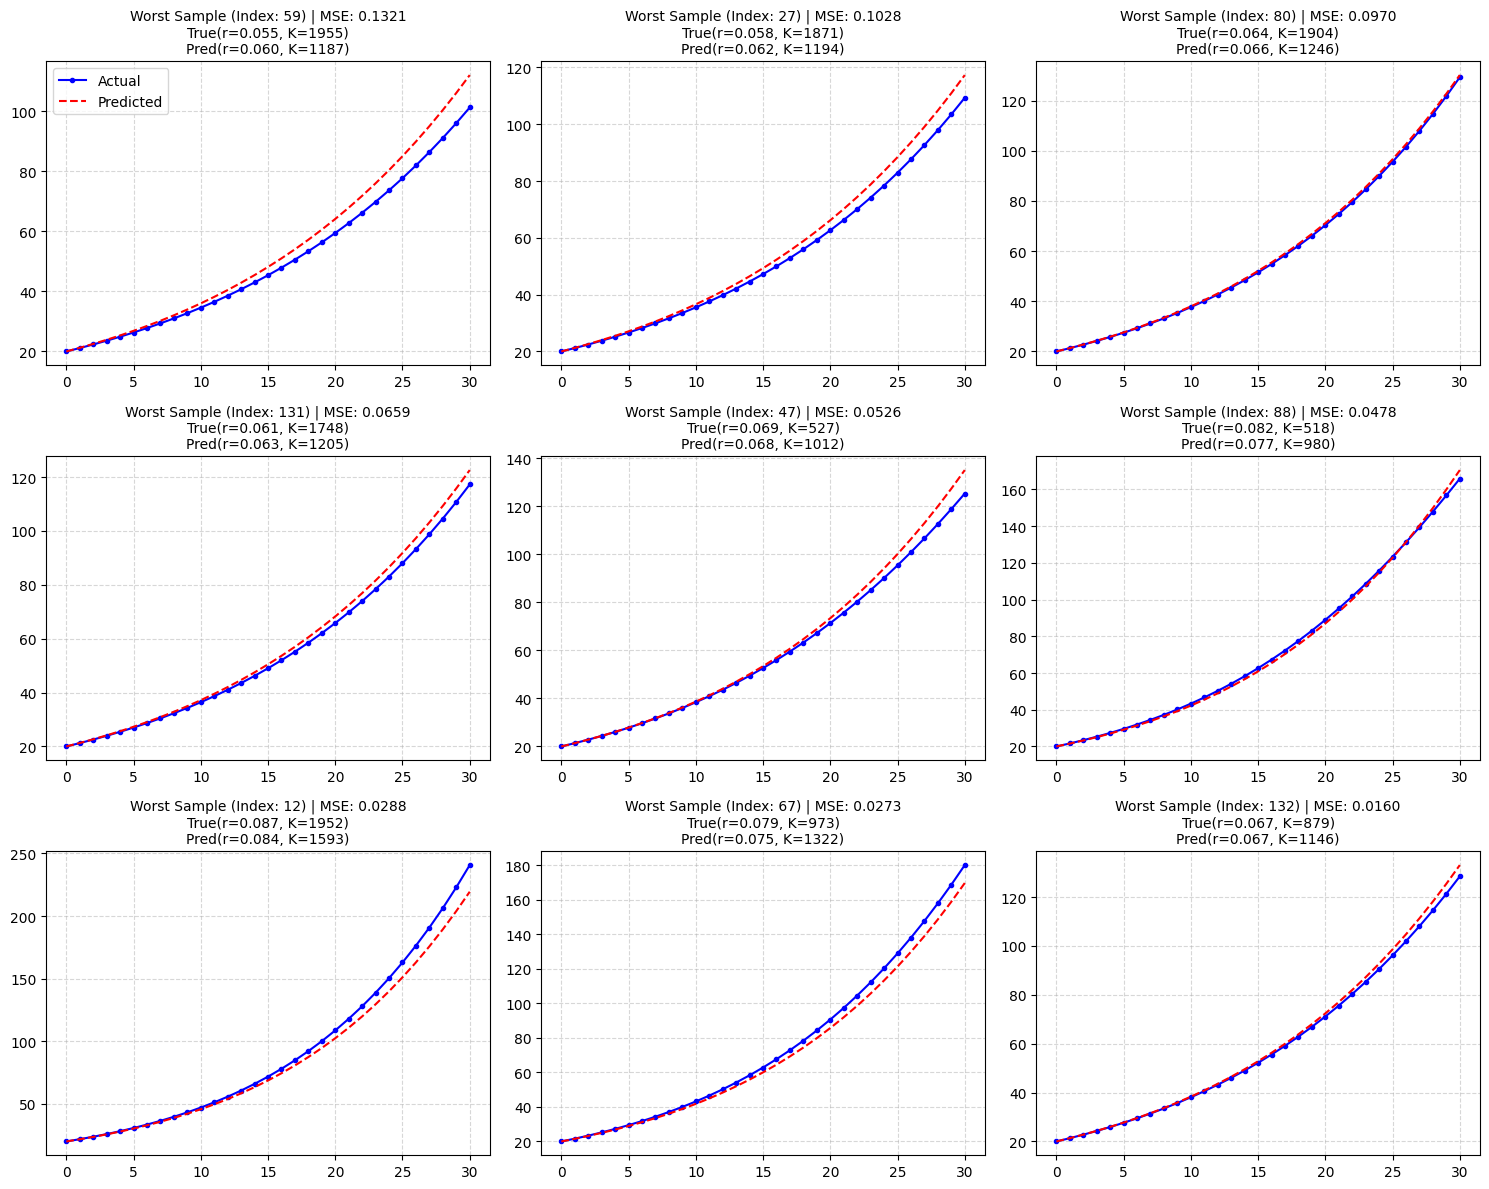

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. GENERATE PREDICTIONS ──
# Generate predictions for the entire test set
y_pred_scaled_all = model.predict(X_test, verbose=0)

# Inverse transform y_test (true values) and y_pred_scaled_all (predicted values)
y_true_unscaled = scaler_y.inverse_transform(y_test)
y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled_all)

# ── 2. CALCULATE ERRORS AND FIND THE WORST PREDICTIONS ──
# Calculate Mean Squared Error (MSE) for each sample using the SCALED values
# We use scaled values so that both r and K contribute equally to the error calculation
sample_errors = np.mean((y_test - y_pred_scaled_all) ** 2, axis=1)

# Get the indices of the samples, sorted by error in DESCENDING order (highest error first)
# np.argsort sorts ascending, so [::-1] reverses it to descending
worst_indices = np.argsort(sample_errors)[::-1]

# ── 3. VISUALIZE THE WORST 9 PREDICTIONS ──
num_samples = 9
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() # Flatten the axes array for easy iteration

print(f"Displaying the top {num_samples} curves with the highest prediction errors...")

for i in range(num_samples):
    # Extract the index of the i-th worst prediction
    idx = worst_indices[i]

    # Extract the true and predicted values for this specific sample
    r_true, K_true = y_true_unscaled[idx]
    r_pred, K_pred = y_pred_unscaled[idx]

    # Reconstruct the curves using the logic you defined previously
    original_curve = logistic_growth(t_31, r_true, K_true, P0_fixed)
    reconstructed_curve = logistic_growth(t_31, r_pred, K_pred, P0_fixed)

    # Plot on the i-th subplot
    axes[i].plot(t_31, original_curve, label='Actual', color='blue', marker='o', markersize=3)
    axes[i].plot(t_31, reconstructed_curve, label='Predicted', color='red', linestyle='dashed')

    # Set the title for each subplot, including the index and the parameter values
    # Adding the MSE score in the title to show exactly how big the error is
    mse_score = sample_errors[idx]
    axes[i].set_title(f'Worst Sample (Index: {idx}) | MSE: {mse_score:.4f}\n'
                      f'True(r={r_true:.3f}, K={K_true:.0f})\n'
                      f'Pred(r={r_pred:.3f}, K={K_pred:.0f})', fontsize=10)

    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Show the legend only in the first subplot to avoid visual clutter
    if i == 0:
        axes[i].legend(loc='best')

plt.tight_layout() # Adjust subplot spacing to prevent overlapping
plt.show()

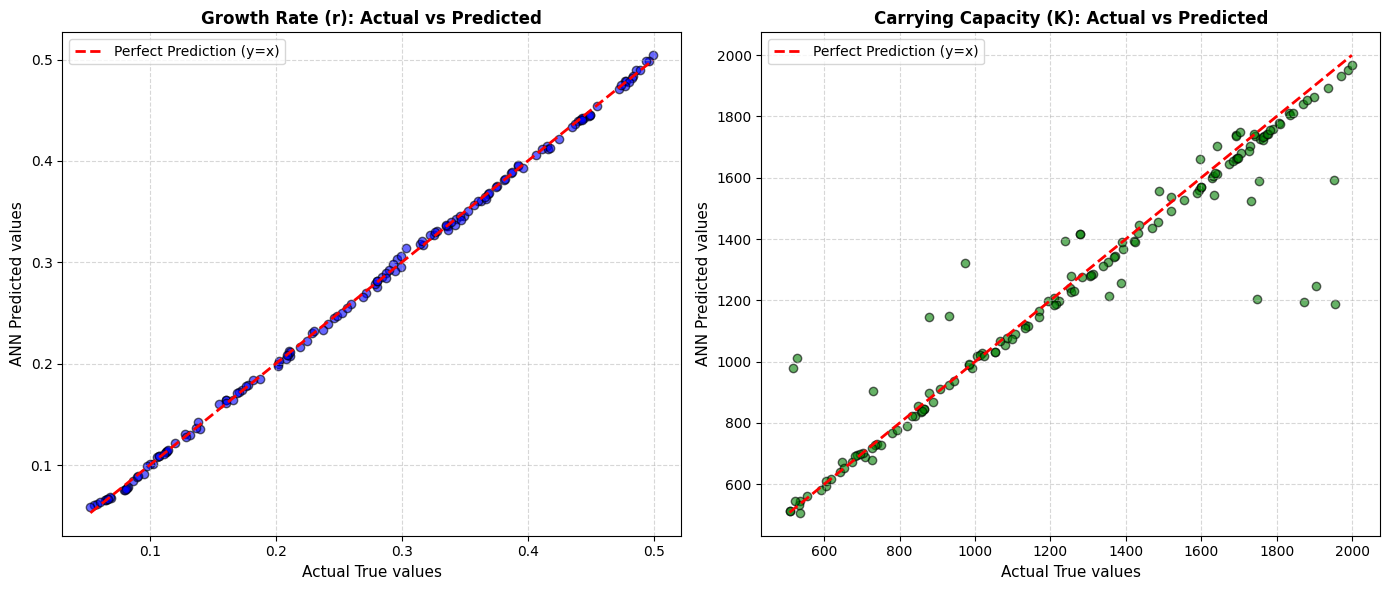

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract r and K values from the unscaled arrays
# Index 0 is for Growth Rate (r), Index 1 is for Carrying Capacity (K)
r_true = y_true_unscaled[:, 0]
r_pred = y_pred_unscaled[:, 0]

K_true = y_true_unscaled[:, 1]
K_pred = y_pred_unscaled[:, 1]

# Create a figure with 1 row and 2 columns (for r and K side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# Plot 1: Actual vs Predicted for Growth Rate (r)
# ==========================================
ax1.scatter(r_true, r_pred, color='blue', alpha=0.6, edgecolor='k')

# Draw the ideal diagonal line (y = x) where True == Predicted
min_r, max_r = min(r_true), max(r_true)
ax1.plot([min_r, max_r], [min_r, max_r], color='red', linestyle='dashed', linewidth=2, label='Perfect Prediction (y=x)')

ax1.set_title('Growth Rate (r): Actual vs Predicted', fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual True values', fontsize=11)
ax1.set_ylabel('ANN Predicted values', fontsize=11)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# Plot 2: Actual vs Predicted for Carrying Capacity (K)
# ==========================================
ax2.scatter(K_true, K_pred, color='green', alpha=0.6, edgecolor='k')

# Draw the ideal diagonal line (y = x) where True == Predicted
min_K, max_K = min(K_true), max(K_true)
ax2.plot([min_K, max_K], [min_K, max_K], color='red', linestyle='dashed', linewidth=2, label='Perfect Prediction (y=x)')

ax2.set_title('Carrying Capacity (K): Actual vs Predicted', fontsize=12, fontweight='bold')
ax2.set_xlabel('Actual True values', fontsize=11)
ax2.set_ylabel('ANN Predicted values', fontsize=11)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np # Import numpy for arange if not already imported

# Define the number of samples to display in the comparison table
# This should match the number of samples you want to compare from the test set
num_samples = 10 # Using 10 as an example, you can adjust this

# Generate predictions for the test set (if not already done)
y_pred_scaled_all = model.predict(X_test, verbose=0)

# Inverse transform the predicted values to get them in the original scale
y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled_all)

# Inverse transform the true values as well
y_true_unscaled = scaler_y.inverse_transform(y_test)

# Create sample labels (e.g., 'Sample 1', 'Sample 2', ...)
sample_labels = [f'Sample {i+1}' for i in range(num_samples)]

# Use the inverse-transformed predicted values for the estimated data
sample_data_estimated = y_pred_unscaled[:num_samples]

# Create a comparison table
comparison_table = pd.DataFrame({
    'Sample ID': sample_labels,
    'True (r)': y_true_unscaled[:num_samples, 0],
    'Estimated (r)': sample_data_estimated[:, 0],
    'True (K)': y_true_unscaled[:num_samples, 1],
    'Estimated (K)': sample_data_estimated[:, 1]
})

print("\n--- Comparison: Ground Truth vs. ANN Estimation ---")
print(comparison_table.to_string(index=False, formatters={
    'True (r)': '{:,.4f}'.format, 'Estimated (r)': '{:,.4f}'.format,
    'True (K)': '{:,.4f}'.format, 'Estimated (K)': '{:,.4f}'.format
}))


--- Comparison: Ground Truth vs. ANN Estimation ---
Sample ID True (r) Estimated (r)   True (K) Estimated (K)
 Sample 1   0.3168        0.3174 1,370.1293    1,343.1207
 Sample 2   0.1734        0.1740   619.1291      618.4063
 Sample 3   0.4993        0.5043 1,899.6700    1,863.0212
 Sample 4   0.4402        0.4393 1,869.8608    1,840.6205
 Sample 5   0.3688        0.3677 1,755.5200    1,726.7694
 Sample 6   0.4960        0.4991   847.5076      854.3676
 Sample 7   0.0958        0.0910   729.2887      902.6829
 Sample 8   0.4153        0.4151 1,484.7179    1,456.3425
 Sample 9   0.4553        0.4539 1,132.5814    1,119.8694
Sample 10   0.1129        0.1132 1,692.9010    1,738.9854


# Real Data - World Bank

In [ ]:
# Install required libraries
# wbgapi  : official World Bank data API wrapper
!pip install wbgapi scipy tensorflow --quiet

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wbgapi as wb
import random
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Download population data from the World Bank (1990–2020)
# Indicator SP.POP.TOTL = Total Population
VARIABLE_CODE = 'SP.POP.TOTL'
TIME_RANGE    = range(1990, 2021)   # 31 years: 1990, 1991, ..., 2020
N_TIME_STEPS  = len(list(TIME_RANGE))  # = 31

print("Fetching real population data from the World Bank...")
data_raw = wb.data.DataFrame(VARIABLE_CODE, time=TIME_RANGE)

# Build a country-code → country-name lookup table
try:
    economy_info  = wb.economy.DataFrame()
    code_to_name  = economy_info['name'].to_dict()
except Exception:
    code_to_name = {}  # fallback if the API call fails

# Cleaning
# Drop rows (countries) with ANY missing value across the 61 years
data_clean = data_raw.dropna(axis=0, how='any')

# Transpose so rows = years, columns = country codes
data_clean = data_clean.T

# Convert the index from 'YR1960' strings to plain integers
data_clean.index = data_clean.index.str.replace('YR', '').astype(int)

print(f"Countries with complete data (no missing years): {data_clean.shape[1]}")
print(f"Years available: {data_clean.index.min()} – {data_clean.index.max()}\n")

Fetching real population data from the World Bank...
Countries with complete data (no missing years): 265
Years available: 1990 – 2020



Displaying population curves for 100 regions (31 Time Steps).


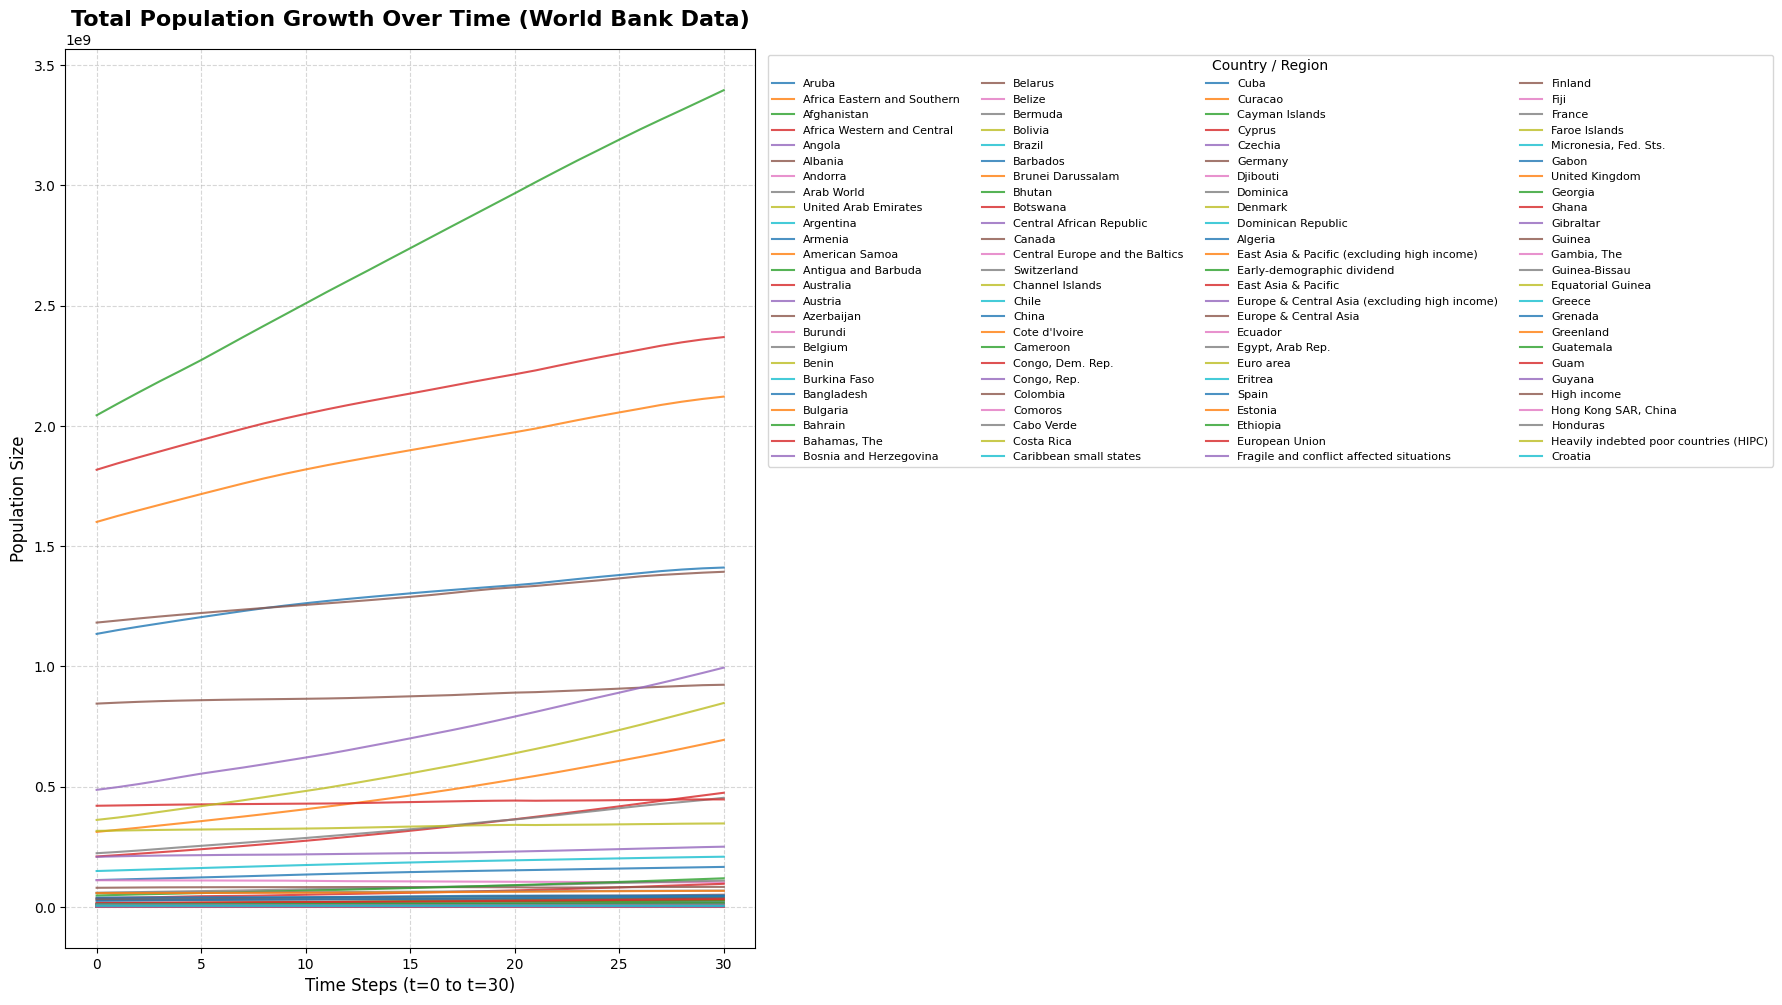

In [ ]:
# Visualise raw population curves (first 100 countries)

selected_columns = data_clean.columns[:100]
data_subset      = data_clean[selected_columns]

data_subset = data_subset.tail(31)

print(f"Displaying population curves for {len(selected_columns)} regions (31 Time Steps).")

plt.figure(figsize=(18, 10))

time_steps = range(31)

for country_code in data_subset.columns:
    country_name = code_to_name.get(country_code, country_code)

    plt.plot(time_steps, data_subset[country_code],
             alpha=0.8, linewidth=1.5, label=country_name)

plt.title('Total Population Growth Over Time (World Bank Data)',
          fontweight='bold', fontsize=16)

plt.xlabel('Time Steps (t=0 to t=30)', fontsize=12)
plt.ylabel('Population Size', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Country / Region',
           bbox_to_anchor=(1.01, 1), loc='upper left',
           ncol=4, fontsize=8, title_fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
t_axis = np.arange(N_TIME_STEPS, dtype=float)

X_data = []   # Input  : normalized population curve
country_names_kept = []

print("Mempersiapkan dan menormalisasi data riil...")

for country_code in data_clean.columns:
    # Memotong data agar jumlah waktunya pas dengan N_TIME_STEPS
    # Jika ANN dilatih dengan 31 data, kita ambil 31 tahun terakhir
    pop_series = data_clean[country_code].tail(N_TIME_STEPS).values.astype(float)

    # Normalise the series to [0, 1]
    pop_min = pop_series.min()
    pop_max = pop_series.max()

    if pop_max - pop_min < 1e-6:
        continue

    pop_norm = (pop_series - pop_min) / (pop_max - pop_min)  # values in [0,1]

    X_data.append(pop_norm)
    country_names_kept.append(code_to_name.get(country_code, country_code))

X_data = np.array(X_data)

print(f"\nTotal negara siap diproses: {len(X_data)}")
print(f"Shape of X (Inputs) : {X_data.shape}  → (Samples, TimePoints)")


Mempersiapkan dan menormalisasi data riil...

Total negara siap diproses: 265
Shape of X (Inputs) : (265, 31)  → (Samples, TimePoints)


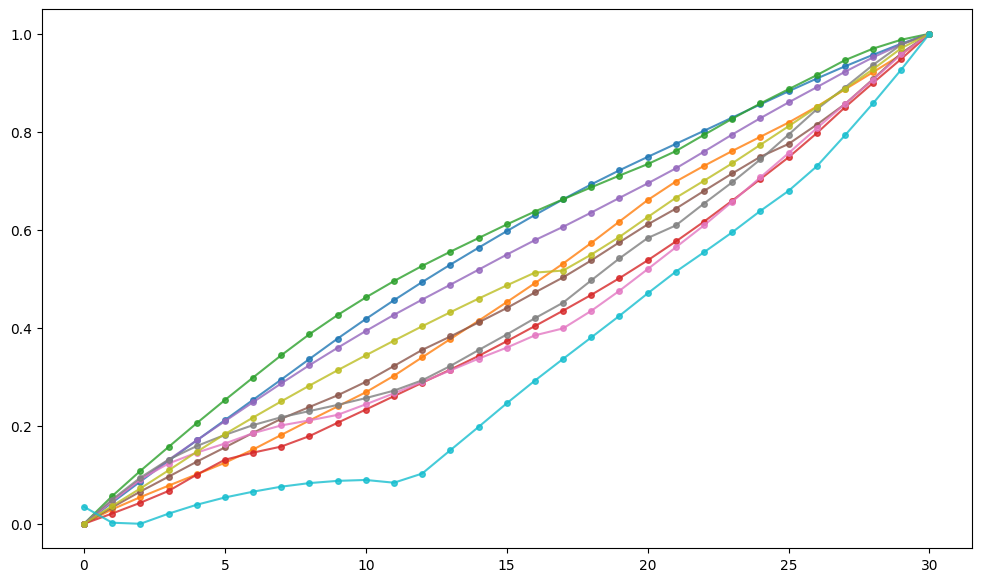

In [ ]:
import random

# Get 10 random indices from your dataset
random_indices = random.sample(range(len(X_data)), min(10, len(X_data)))

plt.figure(figsize=(12, 7))

for i in random_indices:
    plt.plot(t_axis, X_data[i], marker='o', markersize=4, alpha=0.8,
             label=country_names_kept[i])

In [ ]:
# PROSES INFERENCE (MENGGUNAKAN ANN)
print("\nMeminta ANN memprediksi r dan K (Tanpa bantuan rumus matematika)...")
y_pred = model.predict(X_data, verbose=0)

if len(y_pred) > 0:
    print(f"\nContoh hasil untuk negara pertama ('{country_names_kept[0]}'):")
    print(f"  Tebakan ANN: r = {y_pred[0, 0]:.4f},  K = {y_pred[0, 1]:.4f}")


Meminta ANN memprediksi r dan K (Tanpa bantuan rumus matematika)...

Contoh hasil untuk negara pertama ('Aruba'):
  Tebakan ANN: r = 1.8047,  K = 0.8181


Generating plots for the first 9 countries...


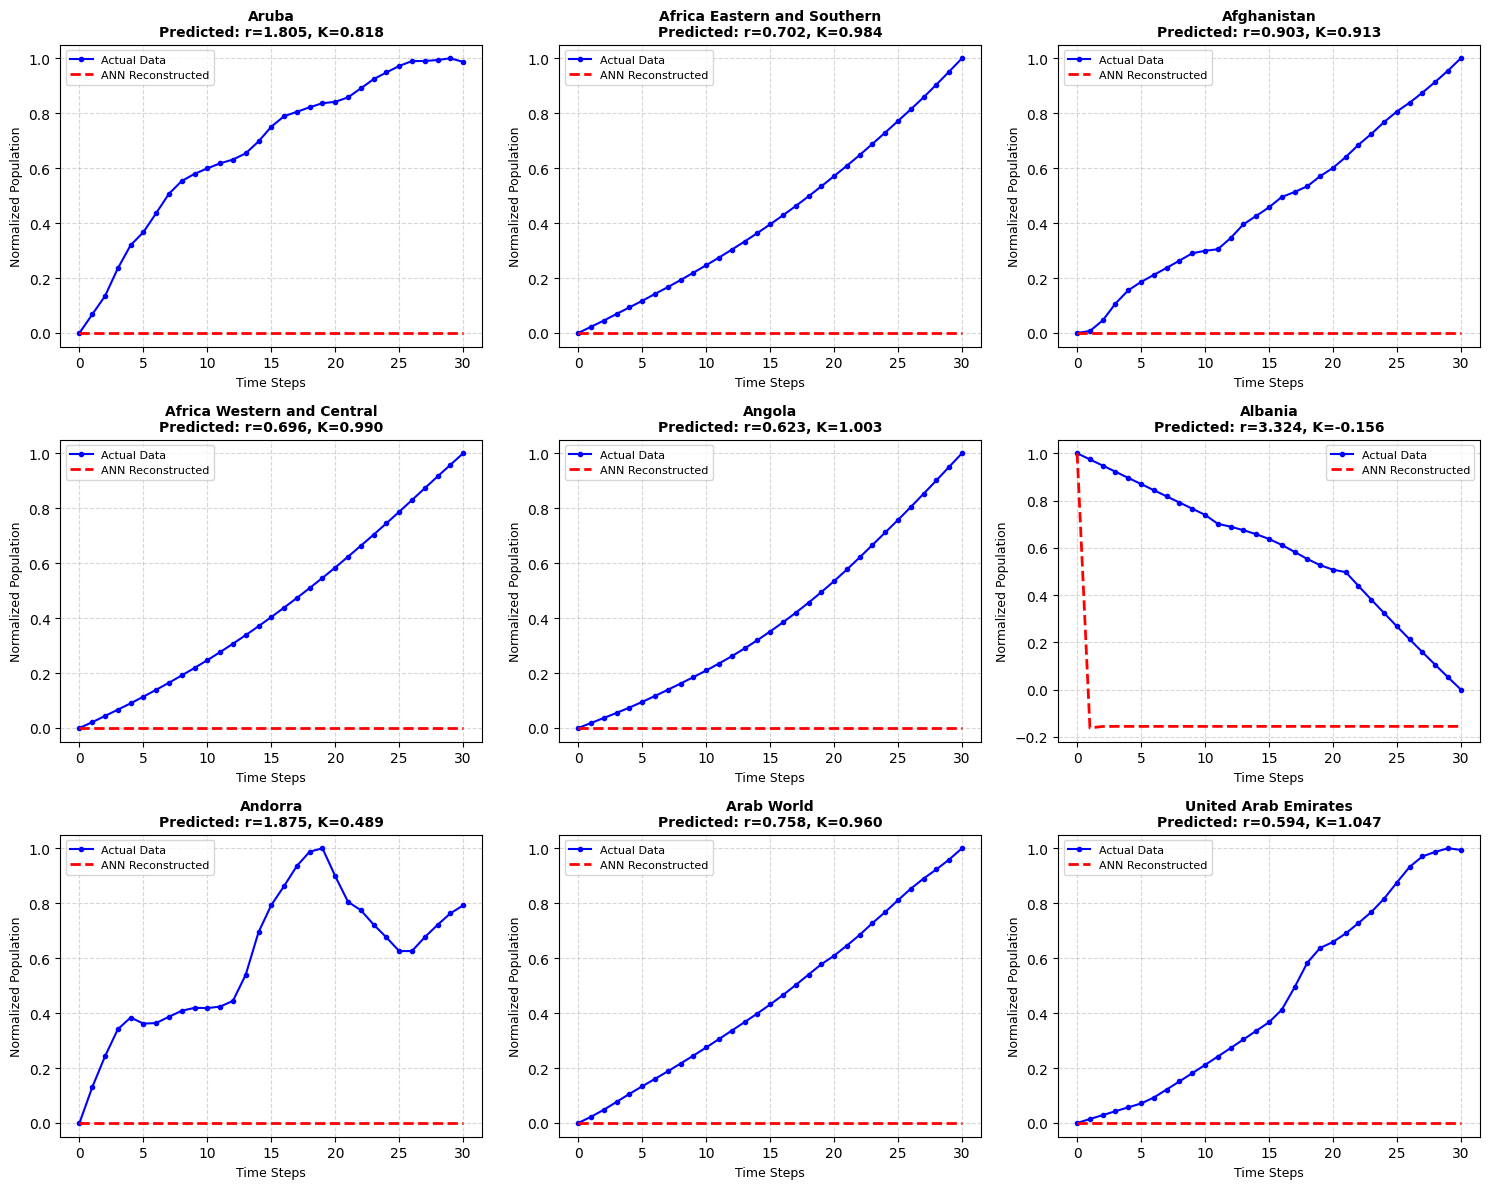

Real data visualization with ANN predictions completed successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINE SAMPLING RANGE
# Select how many real-world samples to display (e.g., 9 samples for a 3x3 grid)
num_samples = min(9, len(X_data))

# Create a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() # Flatten the axes array for easy iteration

print(f"Generating plots for the first {num_samples} countries...")

# 2. PLOT ACTUAL VS ANN PREDICTION FOR EACH COUNTRY
for i in range(num_samples):
    # Extract the actual normalized curve
    actual_curve = X_data[i]

    # Extract P0 (initial population at t=0) directly from the real data
    # This is crucial so the reconstructed curve starts at the exact same point
    P0_actual = actual_curve[0]

    # Extract the parameters predicted by the ANN model
    r_pred = y_pred[i][0]
    K_pred = y_pred[i][1]

    # Reconstruct the curve using the ANN predicted parameters
    # Note: Make sure 'logistic_growth' matches your exact function name
    predicted_curve = logistic_growth(t_axis, r_pred, K_pred, P0_actual)

    # Plot Actual Data (Solid Blue Line with Dots)
    axes[i].plot(t_axis, actual_curve, label='Actual Data', color='blue', marker='o', markersize=3)

    # Plot ANN Prediction Curve (Dashed Red Line)
    axes[i].plot(t_axis, predicted_curve, label='ANN Reconstructed', color='red', linestyle='dashed', linewidth=2)

    # Set the title and labels for each subplot
    country_name = country_names_kept[i]
    axes[i].set_title(f'{country_name}\nPredicted: r={r_pred:.3f}, K={K_pred:.3f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Time Steps', fontsize=9)
    axes[i].set_ylabel('Normalized Population', fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='best', fontsize=8)

# 3. CLEAN UP UNUSED SUBPLOTS
# If there are fewer than 9 countries, remove the empty subplots from the grid
for j in range(num_samples, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust subplot spacing to prevent overlapping
plt.show()

print("Real data visualization with ANN predictions completed successfully!")

Train ANN with Real Data

Building model_2 architecture (31 -> 64 -> 64 -> 32 -> 2)...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,354 (32.63 KB)

 Trainable params: 8,354 (32.63 KB)

 Non-trainable params: 0 (0.00 B)


Training model_2 with synthetic data...
Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1602 - mae: 0.3065 - val_loss: 0.0529 - val_mae: 0.1702
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0557 - mae: 0.1760 - val_loss: 0.0416 - val_mae: 0.1377
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0420 - mae: 0.1391 - val_loss: 0.0350 - val_mae: 0.1311
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0363 - mae: 0.1323 - val_loss: 0.0307 - val_mae: 0.1231
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0333 - mae: 0.1297 - val_loss: 0.0282 - val_mae: 0.1172
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0314 - mae: 0.1246 - val_loss: 0.0258 - val_mae: 0.1118
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0281 - mae: 0.1166 - val_loss: 0.0241 - val_mae: 0.1096
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0260 - mae: 0.1117 - val_loss: 0.0229 - val_mae: 0.1104
Epoch 9/200
18/18 ━━━━

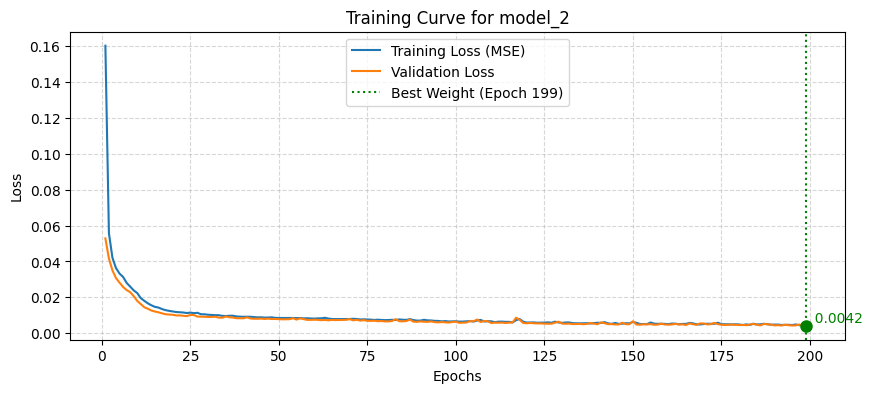

model_2 training complete! Ready for real data prediction.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

print("Building model_2 architecture (31 -> 64 -> 64 -> 32 -> 2)...")

# 1. DEFINE EXACT ARCHITECTURE FROM GUIDELINE
model_2 = Sequential([
    # First hidden layer (64 neurons) accepting 31 time steps
    Dense(64, activation='relu', input_shape=(31,)),

    # Second hidden layer (64 neurons)
    Dense(64, activation='relu'),

    # Third hidden layer (32 neurons)
    Dense(32, activation='relu'),

    # Output layer (2 neurons for r and K, using linear activation)
    Dense(2, activation='linear')
])

# 2. COMPILE MODEL
# Using Adam optimizer with learning rate 0.001 as specified
optimizer = Adam(learning_rate=0.001)

# Using Mean Squared Error (MSE) as the standard loss function for this regression task
model_2.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

model_2.summary()

# 3. TRAIN THE NEW MODEL
print("\nTraining model_2 with synthetic data...")
# NOTE: Ensure X_train and y_train match your actual synthetic data variables!
# Training with 200 epochs and batch_size of 32 as specified in the image
history_2 = model_2.fit(
    X_train, y_train,
    validation_split=0.2, # Reserve 20% of the training data for validation
    epochs=200,
    batch_size=32,
    verbose=1
)

# 4. PLOT TRAINING HISTORY (To monitor learning progress)
import matplotlib.pyplot as plt

# Extract the loss values from the training history
training_loss = history_2.history['loss']
validation_loss = history_2.history['val_loss']

# Create an array of epoch numbers (starting from 1)
epochs_range = range(1, len(training_loss) + 1)

# Find the epoch with the lowest validation loss (Best Weight)
best_val_loss = min(validation_loss)
best_epoch = validation_loss.index(best_val_loss) + 1  # Add 1 because Python index starts at 0

plt.figure(figsize=(10, 4))

# Plot the training and validation loss curves
plt.plot(epochs_range, training_loss, label='Training Loss (MSE)')
plt.plot(epochs_range, validation_loss, label='Validation Loss')

# ── HIGHLIGHT THE BEST WEIGHT ──
# Plot a green dot at the lowest validation loss
plt.plot(best_epoch, best_val_loss, marker='o', color='green', markersize=8)

# Draw a vertical dashed line to make the epoch easy to see
plt.axvline(x=best_epoch, color='green', linestyle=':', label=f'Best Weight (Epoch {best_epoch})')

# Add text to display the exact minimum loss value next to the dot
plt.text(best_epoch, best_val_loss, f'  {best_val_loss:.4f}', color='green', verticalalignment='bottom')

plt.title('Training Curve for model_2')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# loc='best' ensures the legend doesn't cover the green dot
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("model_2 training complete! Ready for real data prediction.")

Generating predictions using model_2...
Displaying the top 9 real-data curves with the lowest reconstruction errors...


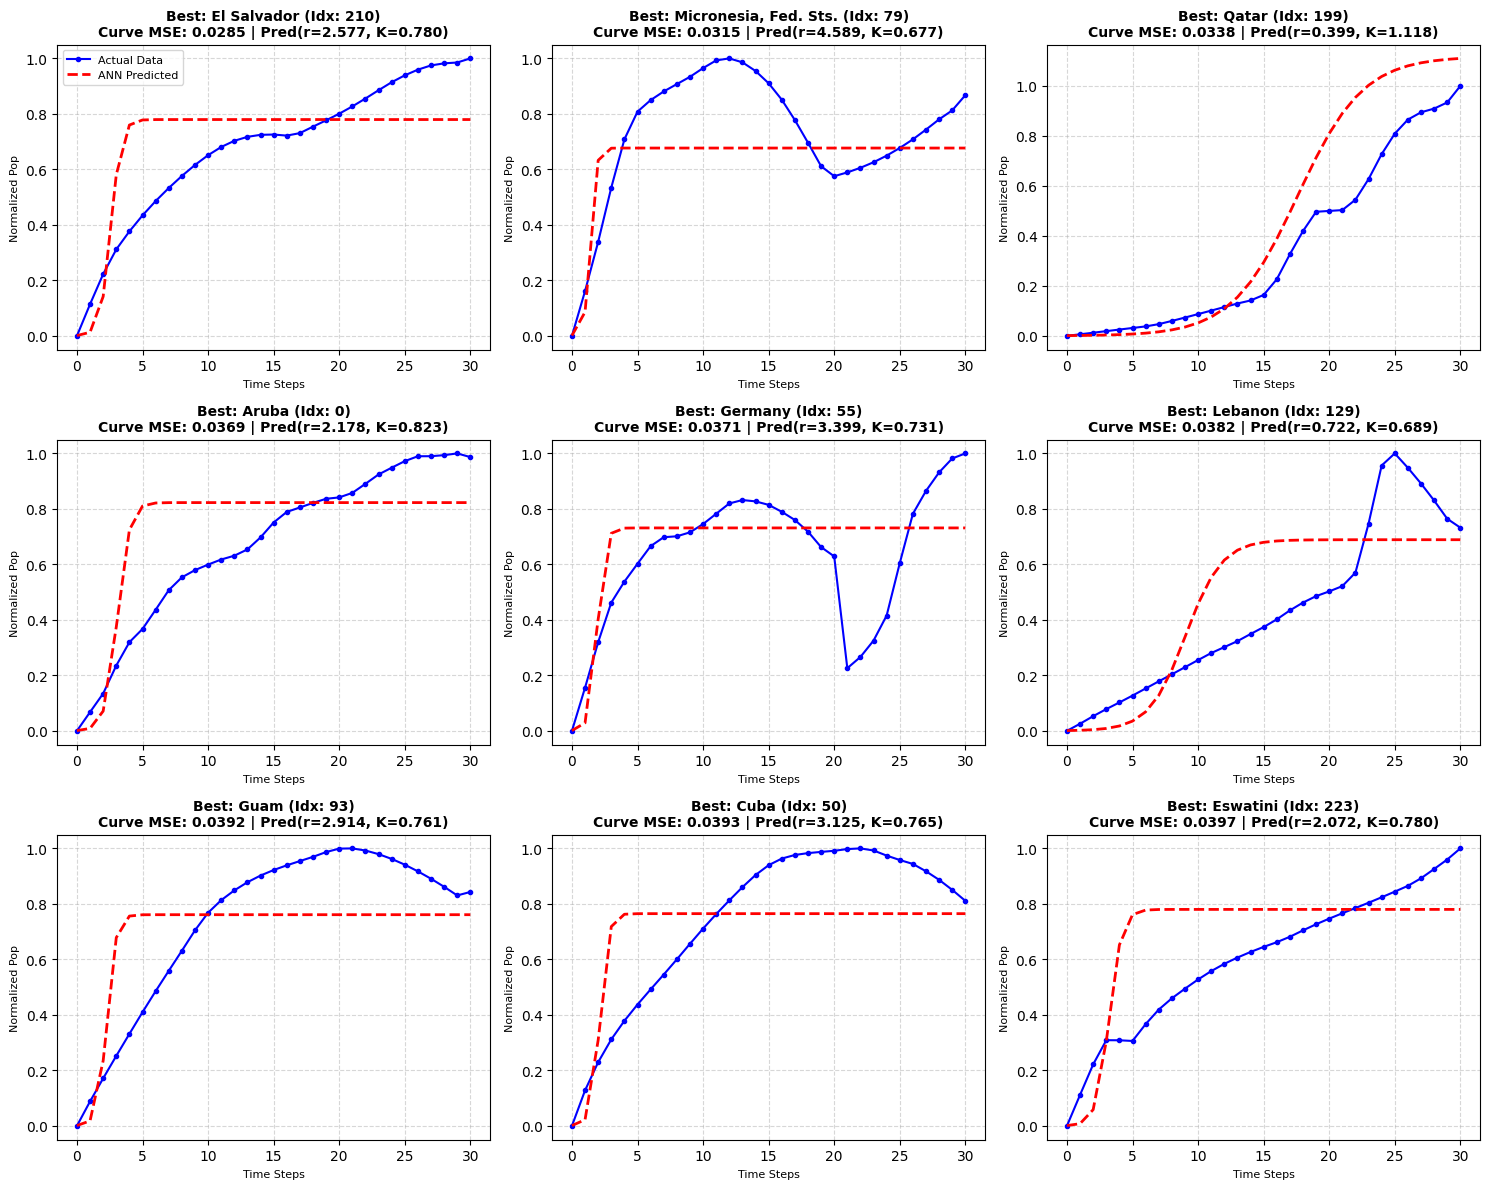

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. GENERATE PREDICTIONS ──
# Generate predictions for the real data using model_2
print("Generating predictions using model_2...")
y_pred_real = model_2.predict(X_data, verbose=0)

# ── 2. CALCULATE RECONSTRUCTION ERRORS ──
# Since we don't have true r and K for real data, we calculate the error
# by comparing the actual curve points with the ANN's reconstructed curve points.
sample_errors = []
reconstructed_curves_all = []

for i in range(len(X_data)):
    actual_curve = X_data[i]
    # IMPORTANT: Prevent division by zero error for P0
    P0_actual = max(actual_curve[0], 0.001)

    r_pred = y_pred_real[i][0]
    K_pred = y_pred_real[i][1]

    # Reconstruct the curve using the logistic growth formula
    pred_curve = logistic_growth(t_axis, r_pred, K_pred, P0_actual)
    reconstructed_curves_all.append(pred_curve)

    # Calculate MSE between the actual data points and predicted curve points
    curve_mse = np.mean((actual_curve - pred_curve) ** 2)
    sample_errors.append(curve_mse)

sample_errors = np.array(sample_errors)

# ── PERUBAHAN UTAMA DI SINI ──
# Get indices sorted by lowest curve reconstruction error (ascending)
# Menghapus [::-1] agar urutannya dari error terkecil ke terbesar
best_indices = np.argsort(sample_errors)

# ── 3. VISUALIZE THE BEST 9 PREDICTIONS ──
num_samples = min(9, len(X_data))
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

print(f"Displaying the top {num_samples} real-data curves with the lowest reconstruction errors...")

for i in range(num_samples):
    # Extract the index of the i-th best prediction
    idx = best_indices[i]

    actual_curve = X_data[idx]
    reconstructed_curve = reconstructed_curves_all[idx]

    r_pred = y_pred_real[idx][0]
    K_pred = y_pred_real[idx][1]
    country_name = country_names_kept[idx]

    # Plot on the i-th subplot
    axes[i].plot(t_axis, actual_curve, label='Actual Data', color='blue', marker='o', markersize=3)
    axes[i].plot(t_axis, reconstructed_curve, label='ANN Predicted', color='red', linestyle='dashed', linewidth=2)

    # Set title including Country Name, MSE score, and predicted parameters
    mse_score = sample_errors[idx]

    # Ubah teks title menjadi 'Best'
    axes[i].set_title(f'Best: {country_name} (Idx: {idx})\n'
                      f'Curve MSE: {mse_score:.4f} | Pred(r={r_pred:.3f}, K={K_pred:.3f})',
                      fontsize=10, fontweight='bold')

    axes[i].set_xlabel('Time Steps', fontsize=8)
    axes[i].set_ylabel('Normalized Pop', fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.5)

    if i == 0:
        axes[i].legend(loc='best', fontsize=8)

# Remove unused subplots if there are fewer than 9 countries
for j in range(num_samples, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Model Evaluation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_models_comprehensive(model_list, X_test, y_test, scaler_y, t_steps=31):
    """
    Evaluates a list of models based on r, K parameters and the actual population curve (Error P).
    """
    results = []

    # Define time axis for curve reconstruction
    t_axis = np.arange(t_steps)

    for model, name in model_list:
        print(f"Evaluating {name}...")

        # 1. Predictions
        y_pred_scaled = model.predict(X_test, verbose=0)
        y_true_unscaled = scaler_y.inverse_transform(y_test)
        y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled)

        # 2. Parameter Errors (r and K)
        rmse_r = np.sqrt(mean_squared_error(y_true_unscaled[:, 0], y_pred_unscaled[:, 0]))
        rmse_k = np.sqrt(mean_squared_error(y_true_unscaled[:, 1], y_pred_unscaled[:, 1]))
        mae_r = mean_absolute_error(y_true_unscaled[:, 0], y_pred_unscaled[:, 0])
        mae_k = mean_absolute_error(y_true_unscaled[:, 1], y_pred_unscaled[:, 1])

        # 3. Population Error (Error P / Curve Error)
        # We reconstruct the population curve for every test sample and compare actual vs predicted
        curve_mse_list = []
        curve_mae_list = []

        for i in range(len(X_test)):
            # Use P0 from the actual data (first point) to make comparison fair
            # In your synthetic data, this is usually X_test_unscaled[:, 0]
            P0 = max(X_test[i, 0], 0.001)

            # True Curve
            curve_true = logistic_growth(t_axis, y_true_unscaled[i, 0], y_true_unscaled[i, 1], P0)
            # Predicted Curve
            curve_pred = logistic_growth(t_axis, y_pred_unscaled[i, 0], y_pred_unscaled[i, 1], P0)

            curve_mse_list.append(mean_squared_error(curve_true, curve_pred))
            curve_mae_list.append(mean_absolute_error(curve_true, curve_pred))

        rmse_p = np.sqrt(np.mean(curve_mse_list))
        mae_p = np.mean(curve_mae_list)

        # 4. Append to results
        results.append({
            "Model": name,
            "RMSE (r)": rmse_r,
            "RMSE (K)": rmse_k,
            "RMSE (Population)": rmse_p,
            "MAE (r)": mae_r,
            "MAE (K)": mae_k,
            "MAE (Population)": mae_p
        })

    return pd.DataFrame(results)

# --- EXECUTION ---
# List your models here
model_list = [
    (model, "Model_1"),
    (model_2, "Model_2")
]

# Run the comprehensive evaluation
comparison_df = evaluate_models_comprehensive(model_list, X_test, y_test, scaler_y)

# Display the comparison table
print("\n--- Model Evaluation ---")
print(comparison_df.to_string(index=False))

Evaluating Model_1...
Evaluating Model_2...

--- Model Evaluation ---
  Model  RMSE (r)   RMSE (K)  RMSE (Population)  MAE (r)   MAE (K)  MAE (Population)
Model_1  0.002892 138.809114           3.326933 0.002266 59.954265          0.588755
Model_2  0.007433 184.511320          11.675526 0.005820 86.038624          2.166398


In [ ]:
import pandas as pd

# ── CREATE A DATAFRAME FOR THE RESULTS ──
# We select the first 10 countries from the processed list
num_samples = 10
sample_names = country_names_kept[:num_samples]
sample_predictions = y_pred_real[:num_samples]

# Constructing the table
results_table = pd.DataFrame({
    'Country / Region': sample_names,
    'Estimated (r)': sample_predictions[:, 0],
    'Estimated (K)': sample_predictions[:, 1]
})

# Displaying the results formatted
print("--- Sample of ANN Parameter Estimations (First 10 Regions) ---")
print(results_table.to_string(index=False, formatters={
    'Estimated (r)': '{:,.4f}'.format,
    'Estimated (K)': '{:,.4f}'.format
}))

# ── OPTIONAL: SAVE TO CSV FOR YOUR REPORT ──
# results_table.to_csv("estimated_parameters.csv", index=False)
# print("\nResults have been saved to 'estimated_parameters.csv'")

--- Sample of ANN Parameter Estimations (First 10 Regions) ---
           Country / Region Estimated (r) Estimated (K)
                      Aruba        2.1776        0.8227
Africa Eastern and Southern        0.5620        1.0907
                Afghanistan        0.7429        1.0604
 Africa Western and Central        0.5637        1.0914
                     Angola        0.5044        1.1584
                    Albania        6.9884        0.2068
                    Andorra        2.8035        0.5862
                 Arab World        0.6366        1.0784
       United Arab Emirates        0.5087        1.0802
                  Argentina        0.8918        1.0172


# Analysis

--- ANALYSIS 1: MAXIMUM GROWTH RATE (G_max) ---
Estimated G_max (from ANN) : 48.02 population units/time
True Theoretical G_max     : 50.00 population units/time
Absolute Error             : 1.98

--- ANALYSIS 2: SIMPLE EXTRAPOLATION ---


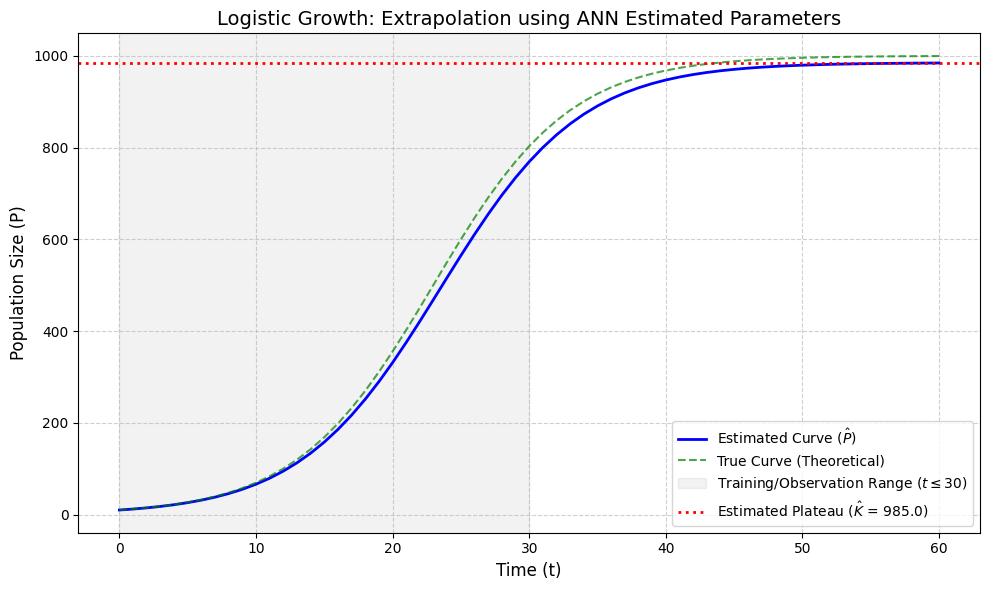

Extrapolation plot successfully generated.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Inputs from your ANN & Data
# ==========================================
# Replace these values with the actual outputs from your ANN model
r_est = 0.195   # Example: Estimated growth rate (\hat{r})
K_est = 985.0   # Example: Estimated carrying capacity (\hat{K})

# Replace these with your actual initial conditions/true parameters (if known)
P0 = 10         # Initial population at t=0
r_true = 0.2    # True r (for comparison)
K_true = 1000.0 # True K (for comparison)


# ==========================================
# ANALYSIS 1: Maximum Growth Rate (G_max)
# ==========================================
print("--- ANALYSIS 1: MAXIMUM GROWTH RATE (G_max) ---")

# Calculate the estimated maximum growth rate using ANN results
G_max_est = (r_est * K_est) / 4

# Calculate the theoretical true maximum growth rate
G_max_true = (r_true * K_true) / 4

print(f"Estimated G_max (from ANN) : {G_max_est:.2f} population units/time")
print(f"True Theoretical G_max     : {G_max_true:.2f} population units/time")
print(f"Absolute Error             : {abs(G_max_true - G_max_est):.2f}\n")


# ==========================================
# ANALYSIS 2: Simple Extrapolation Analysis
# ==========================================
print("--- ANALYSIS 2: SIMPLE EXTRAPOLATION ---")

# Define the time arrays
t_train = np.arange(0, 31)       # t = 0 to 30 (Observation/Training period)
t_extrapolate = np.arange(0, 61) # t = 0 to 60 (Projection period)

# Define the logistic growth function
def logistic_growth(t, r, K, P_initial):
    """Calculates population size P(t) for a given time t."""
    return K / (1 + ((K - P_initial) / P_initial) * np.exp(-r * t))

# 1. Project population using estimated parameters (\hat{r}, \hat{K})
P_est_extrapolated = logistic_growth(t_extrapolate, r_est, K_est, P0)

# 2. Calculate true population for comparison (Optional)
P_true = logistic_growth(t_extrapolate, r_true, K_true, P0)

# 3. Visualization
plt.figure(figsize=(10, 6))

# Plot the extrapolated curve based on ANN estimates
plt.plot(t_extrapolate, P_est_extrapolated, label=r'Estimated Curve ($\hat{P}$)',
         color='blue', linewidth=2)

# Plot the true curve (for reference)
plt.plot(t_extrapolate, P_true, label='True Curve (Theoretical)',
         color='green', linestyle='--', alpha=0.7)

# Highlight the training data region (t=0 to 30)
plt.axvspan(0, 30, color='gray', alpha=0.1, label='Training/Observation Range ($t \leq 30$)')

# Add a horizontal line for the estimated carrying capacity plateau (\hat{K})
plt.axhline(y=K_est, color='red', linestyle=':', linewidth=2,
            label=f'Estimated Plateau ($\hat{{K}}$ = {K_est})')

# Formatting the plot
plt.title('Logistic Growth: Extrapolation using ANN Estimated Parameters', fontsize=14)
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Population Size (P)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()

print("Extrapolation plot successfully generated.")